In [1]:
!pip install sionna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.1/562.1 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 120.0 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found ex

In [2]:
import sionna
import numpy as np
import matplotlib.pyplot as plt

print('sionna imported successfully')
print('NumPy version:', np.__version__)

sionna imported successfully
NumPy version: 2.4.6


# Day 3 — Least Squares Channel Estimation

Today focuses on building a classical Least Squares channel estimation baseline.

The goal is to simulate a simple pilot-based wireless channel estimation system:

`transmitted pilot → wireless channel → noisy received pilot → estimated channel`

This baseline will later be compared against a neural network-based channel estimator.

In [3]:
num_pilots = 64

pilot_symbols = np.ones(num_pilots, dtype=np.complex64)

print("Pilot symbols shape:", pilot_symbols.shape)
print("First 5 pilot symbols:", pilot_symbols[:5])

Pilot symbols shape: (64,)
First 5 pilot symbols: [1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j]


In [4]:
np.random.seed(42)

true_channel = (
    np.random.normal(size=num_pilots)
    + 1j * np.random.normal(size=num_pilots)
) / np.sqrt(2)

print("True channel shape:", true_channel.shape)
print("First 5 true channel values:", true_channel[:5])

True channel shape: (64,)
First 5 true channel values: [ 0.35122995+0.57454252j -0.09776762+0.95900652j  0.45798496-0.05091885j
  1.07694474+0.70960492j -0.16557144+0.25571529j]


In [5]:
received_clean = true_channel * pilot_symbols

print("Received clean signal shape:", received_clean.shape)
print("First 5 clean received values:", received_clean[:5])

Received clean signal shape: (64,)
First 5 clean received values: [ 0.35122995+0.57454252j -0.09776762+0.95900652j  0.45798496-0.05091885j
  1.07694474+0.70960492j -0.16557144+0.25571529j]


In [6]:
snr_db = 10
snr_linear = 10 ** (snr_db / 10)

noise_power = 1 / snr_linear

noise = np.sqrt(noise_power / 2) * (
    np.random.normal(size=num_pilots)
    + 1j * np.random.normal(size=num_pilots)
)

received_noisy = received_clean + noise

print("SNR in dB:", snr_db)
print("Noise power:", noise_power)
print("First 5 noisy received values:", received_noisy[:5])

SNR in dB: 10
Noise power: 0.1
First 5 noisy received values: [ 0.37351267+0.62241534j -0.2103482 +0.68045086j  0.11124607-0.01219441j
  1.09227589+0.7957645j  -0.40310977+0.05807875j]


In [7]:
ls_estimated_channel = received_noisy / pilot_symbols

print("LS estimated channel shape:", ls_estimated_channel.shape)
print("First 5 LS estimates:", ls_estimated_channel[:5])

LS estimated channel shape: (64,)
First 5 LS estimates: [ 0.37351267+0.62241534j -0.2103482 +0.68045086j  0.11124607-0.01219441j
  1.09227589+0.7957645j  -0.40310977+0.05807875j]


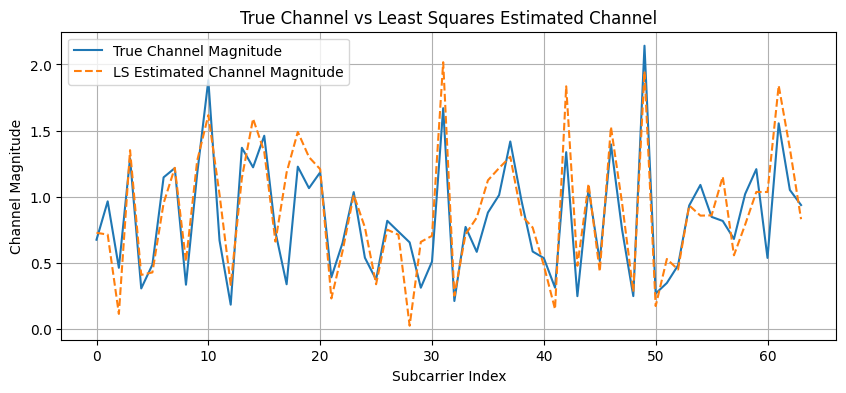

In [8]:
plt.figure(figsize=(10,4))
plt.plot(np.abs(true_channel), label="True Channel Magnitude")
plt.plot(np.abs(ls_estimated_channel), label="LS Estimated Channel Magnitude", linestyle="--")
plt.title("True Channel vs Least Squares Estimated Channel")
plt.xlabel("Subcarrier Index")
plt.ylabel("Channel Magnitude")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
mse = np.mean(np.abs(true_channel - ls_estimated_channel) ** 2)

nmse = mse / np.mean(np.abs(true_channel) ** 2)

print("MSE:", mse)
print("NMSE:", nmse)
print("NMSE in dB:", 10 * np.log10(nmse))

MSE: 0.10035673205496495
NMSE: 0.11221728877867723
NMSE in dB: -9.4994022826029


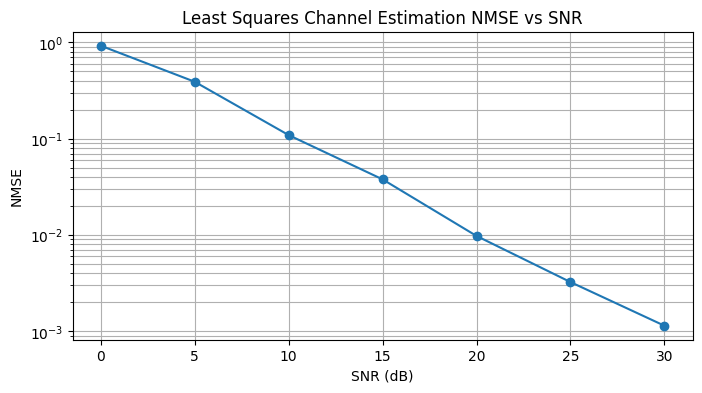

In [10]:
snr_values_db = [0, 5, 10, 15, 20, 25, 30]
nmse_values = []

for snr_db in snr_values_db:
    snr_linear = 10 ** (snr_db / 10)
    noise_power = 1 / snr_linear

    noise = np.sqrt(noise_power / 2) * (
        np.random.normal(size=num_pilots)
        + 1j * np.random.normal(size=num_pilots)
    )

    received_noisy = received_clean + noise
    ls_estimated_channel = received_noisy / pilot_symbols

    mse = np.mean(np.abs(true_channel - ls_estimated_channel) ** 2)
    nmse = mse / np.mean(np.abs(true_channel) ** 2)

    nmse_values.append(nmse)

plt.figure(figsize=(8,4))
plt.semilogy(snr_values_db, nmse_values, marker="o")
plt.title("Least Squares Channel Estimation NMSE vs SNR")
plt.xlabel("SNR (dB)")
plt.ylabel("NMSE")
plt.grid(True, which="both")
plt.show()

## Least Squares NMSE vs SNR

This plot shows how Least Squares channel estimation performs across different signal-to-noise ratio values.

At low SNR, the received pilot symbols are heavily affected by noise, so the LS channel estimate has higher error.

As SNR increases, the noise becomes weaker relative to the signal, and the LS estimate becomes more accurate. This is why the NMSE decreases as SNR increases.

This curve will serve as the classical baseline for comparing the neural network-based channel estimator later in the project.